# HMM-Weighted EGARCH for Bitcoin Volatility Forecasting

## Methodology
This notebook implements a regime-adjusted EGARCH(1,1) model using HMM-derived regime probabilities. 

**Approach:**
1. Fit single EGARCH(1,1) on full rolling window (maintains temporal structure)
2. Adjust forecast based on current regime probability via multiplicative scaling:
   - High-vol regime (prob_high > threshold): scale UP by high_mult
   - Low-vol regime (prob_high < 1-threshold): scale DOWN by low_mult
   - Uncertain regime: no adjustment (mult = 1.0)

**Data split:** 60% train / 25% validation / 15% test  
**Model:** EGARCH(1,1) with Student-t distribution  
**Window:** 365-day rolling window  
**Target:** target_vol (next-day realized volatility)

In [14]:
import pandas as pd
import numpy as np
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from itertools import product

df = pd.read_csv("df_hmm.csv", parse_dates=["date"])
df = df.dropna(subset=['hmm_regime', 'hmm_prob_high']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nRegime distribution:")
print(df['hmm_regime'].value_counts().sort_index())

Dataset shape: (3124, 49)
Date range: 2017-07-13 00:00:00 to 2026-01-30 00:00:00

Regime distribution:
hmm_regime
0.0    1812
1.0    1312
Name: count, dtype: int64


In [15]:
# Train/Val/Test Split (60/25/15)
total_len = len(df)
train_size = int(total_len * 0.60)
val_size = int(total_len * 0.25)

train_end = train_size
val_start = train_size
val_end = train_size + val_size
test_start = val_end

print(f"Train: {0:4d} to {train_end:4d} ({train_size:4d} days) | {df['date'].iloc[0]} to {df['date'].iloc[train_end-1]}")
print(f"Val:   {val_start:4d} to {val_end:4d} ({val_size:4d} days) | {df['date'].iloc[val_start]} to {df['date'].iloc[val_end-1]}")
print(f"Test:  {test_start:4d} to {total_len:4d} ({total_len - test_start:4d} days) | {df['date'].iloc[test_start]} to {df['date'].iloc[-1]}")

# Model specification
window_size = 365
print(f"\nModel: EGARCH(1,1) with Student-t distribution")
print(f"Rolling window: {window_size} days")

Train:    0 to 1874 (1874 days) | 2017-07-13 00:00:00 to 2022-08-29 00:00:00
Val:   1874 to 2655 ( 781 days) | 2022-08-30 00:00:00 to 2024-10-18 00:00:00
Test:  2655 to 3124 ( 469 days) | 2024-10-19 00:00:00 to 2026-01-30 00:00:00

Model: EGARCH(1,1) with Student-t distribution
Rolling window: 365 days


In [3]:
# Hyperparameter Tuning - Grid Search

threshold_values = [0.5, 0.6, 0.7, 0.8]
high_vol_multipliers = [1.1, 1.2, 1.3, 1.5]
low_vol_multipliers = [0.7, 0.8, 0.9]

val_sample_indices = range(val_start, val_end, 5)
grid_results = []
total_configs = len(threshold_values) * len(high_vol_multipliers) * len(low_vol_multipliers)

print(f"Testing {total_configs} configurations on {len([i for i in val_sample_indices if i >= window_size])} samples...")

config_num = 0
for threshold, high_mult, low_mult in product(threshold_values, high_vol_multipliers, low_vol_multipliers):
    config_num += 1
    if config_num % 10 == 0:
        print(f"Progress: {config_num}/{total_configs}")
    
    preds = []
    actuals = []
    
    for i in val_sample_indices:
        if i < window_size:
            continue
        
        train_returns = df.iloc[i - window_size : i]['log_return'].values * 100
        current_prob_high = df.iloc[i]['hmm_prob_high']
        target_val = df.iloc[i]['target_vol']
        
        try:
            model = arch_model(train_returns, vol='EGARCH', p=1, q=1, dist='t', rescale=False)
            res = model.fit(disp='off', show_warning=False)
            
            pred_var = res.forecast(horizon=1).variance.values[-1, 0]
            base_forecast = np.sqrt(max(0, pred_var)) / 100
            
            # Regime adjustment
            if current_prob_high > threshold:
                regime_adj = high_mult
            elif current_prob_high < (1 - threshold):
                regime_adj = low_mult
            else:
                regime_adj = 1.0
            
            ensemble = base_forecast * regime_adj
            ensemble = np.clip(ensemble, 0, 0.15)
            
            preds.append(ensemble)
            actuals.append(target_val)
            
        except:
            fallback = preds[-1] if preds else 0.02
            preds.append(fallback)
            actuals.append(target_val)
    
    if len(preds) > 0:
        preds = np.array(preds)
        actuals = np.array(actuals)
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        
        grid_results.append({
            'threshold': threshold,
            'high_mult': high_mult,
            'low_mult': low_mult,
            'RMSE': rmse
        })

results_df = pd.DataFrame(grid_results).sort_values('RMSE')
print("\n" + "="*70)
print("TOP 10 CONFIGURATIONS")
print("="*70)
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0]
best_threshold = best_config['threshold']
best_high_mult = best_config['high_mult']
best_low_mult = best_config['low_mult']

print(f"\n" + "="*70)
print("BEST CONFIGURATION")
print("="*70)
print(f"Threshold:       {best_threshold}")
print(f"High-vol mult:   {best_high_mult}")
print(f"Low-vol mult:    {best_low_mult}")
print(f"Validation RMSE: {best_config['RMSE']:.6f}")
print("="*70)

Testing 48 configurations on 173 samples...
Progress: 10/48
Progress: 20/48
Progress: 30/48
Progress: 40/48

TOP 10 CONFIGURATIONS
 threshold  high_mult  low_mult     RMSE
       0.8        1.1       0.7 0.025168
       0.7        1.1       0.7 0.025209
       0.6        1.1       0.7 0.025231
       0.5        1.1       0.7 0.025240
       0.8        1.1       0.8 0.025692
       0.7        1.1       0.8 0.025715
       0.6        1.1       0.8 0.025736
       0.5        1.1       0.8 0.025745
       0.8        1.1       0.9 0.026478
       0.7        1.1       0.9 0.026487

BEST CONFIGURATION
Threshold:       0.8
High-vol mult:   1.1
Low-vol mult:    0.7
Validation RMSE: 0.025168


In [16]:
best_threshold = 0.8
best_high_mult = 1.1
best_low_mult = 0.7

In [17]:
# Full Validation with Best Parameters

val_preds = []
val_actuals = []
val_dates = []

failures = 0

print(f"\nRunning full validation with tuned parameters...")
print(f"  Threshold: {best_threshold}")
print(f"  High-vol multiplier: {best_high_mult}")
print(f"  Low-vol multiplier: {best_low_mult}\n")

for i in range(val_start, val_end):
    if i < window_size:
        continue
    
    train_returns = df.iloc[i - window_size : i]['log_return'].values * 100
    current_prob_high = df.iloc[i]['hmm_prob_high']
    target_val = df.iloc[i]['target_vol']
    current_date = df.iloc[i]['date']
    
    try:
        model = arch_model(train_returns, vol='EGARCH', p=1, q=1, dist='t', rescale=False)
        res = model.fit(disp='off', show_warning=False)
        
        pred_var = res.forecast(horizon=1).variance.values[-1, 0]
        base_forecast = np.sqrt(max(0, pred_var)) / 100
        
        # Apply tuned regime adjustment
        if current_prob_high > best_threshold:
            regime_adj = best_high_mult
        elif current_prob_high < (1 - best_threshold):
            regime_adj = best_low_mult
        else:
            regime_adj = 1.0
        
        ensemble = base_forecast * regime_adj
        ensemble = np.clip(ensemble, 0, 0.15)
        
        val_preds.append(ensemble)
        val_actuals.append(target_val)
        val_dates.append(current_date)
        
    except:
        failures += 1
        fallback = val_preds[-1] if val_preds else 0.02
        val_preds.append(fallback)
        val_actuals.append(target_val)
        val_dates.append(current_date)

val_preds = np.array(val_preds)
val_actuals = np.array(val_actuals)

val_rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = np.mean(val_actuals / (val_preds + 1e-10) - np.log(val_actuals / (val_preds + 1e-10)) - 1)

print(f"--- VALIDATION RESULTS ---")
print(f"RMSE:  {val_rmse:.6f}")
print(f"MAE:   {val_mae:.6f}")
print(f"QLIKE: {val_qlike:.6f}")
print(f"Failures: {failures}")
print(f"Samples: {len(val_preds)}")


Running full validation with tuned parameters...
  Threshold: 0.8
  High-vol multiplier: 1.1
  Low-vol multiplier: 0.7

--- VALIDATION RESULTS ---
RMSE:  0.030973
MAE:   0.019421
QLIKE: 13437210.532501
Failures: 0
Samples: 781


In [18]:
# Test Set Evaluation

test_preds = []
test_actuals = []
test_dates = []

failures_test = 0

print(f"\nRunning test set evaluation...")

for i in range(test_start, total_len):
    if i < window_size:
        continue
    
    train_returns = df.iloc[i - window_size : i]['log_return'].values * 100
    current_prob_high = df.iloc[i]['hmm_prob_high']
    target_val = df.iloc[i]['target_vol']
    current_date = df.iloc[i]['date']
    
    try:
        model = arch_model(train_returns, vol='EGARCH', p=1, q=1, dist='t', rescale=False)
        res = model.fit(disp='off', show_warning=False)
        
        pred_var = res.forecast(horizon=1).variance.values[-1, 0]
        base_forecast = np.sqrt(max(0, pred_var)) / 100
        
        # Apply same tuned regime adjustment
        if current_prob_high > best_threshold:
            regime_adj = best_high_mult
        elif current_prob_high < (1 - best_threshold):
            regime_adj = best_low_mult
        else:
            regime_adj = 1.0
        
        ensemble = base_forecast * regime_adj
        ensemble = np.clip(ensemble, 0, 0.15)
        
        test_preds.append(ensemble)
        test_actuals.append(target_val)
        test_dates.append(current_date)
        
    except:
        failures_test += 1
        fallback = test_preds[-1] if test_preds else 0.02
        test_preds.append(fallback)
        test_actuals.append(target_val)
        test_dates.append(current_date)

test_preds = np.array(test_preds)
test_actuals = np.array(test_actuals)

test_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {test_rmse:.6f}")
print(f"MAE:   {test_mae:.6f}")
print(f"QLIKE: {test_qlike:.6f}")
print(f"Failures: {failures_test}")
print(f"Samples: {len(test_preds)}")


Running test set evaluation...

--- TEST RESULTS ---
RMSE:  0.015895
MAE:   0.009559
QLIKE: 1968894.572537
Failures: 0
Samples: 469


In [19]:
# Results Summary

summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike, test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-Weighted EGARCH Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print(f"\nBest Parameters Used:")
print(f"  Threshold: {best_threshold}")
print(f"  High-vol multiplier: {best_high_mult}")
print(f"  Low-vol multiplier: {best_low_mult}")
print("="*60)


HMM-Weighted EGARCH Summary
   Dataset     RMSE      MAE        QLIKE  Samples
Validation 0.030973 0.019421 1.343721e+07      781
      Test 0.015895 0.009559 1.968895e+06      469

Best Parameters Used:
  Threshold: 0.8
  High-vol multiplier: 1.1
  Low-vol multiplier: 0.7


In [ ]:
# Save Results

val_results = pd.DataFrame({
    'date': val_dates,
    'actual': val_actuals,
    'forecast': val_preds,
    'error': val_actuals - val_preds
})

test_results = pd.DataFrame({
    'date': test_dates,
    'actual': test_actuals,
    'forecast': test_preds,
    'error': test_actuals - test_preds
})

Validation results saved to: hmm_egarch_validation.csv
Test results saved to: hmm_egarch_test.csv


In [ ]:
# Visualization

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_n = min(200, len(test_actuals))
plot_dates = test_dates[-plot_n:]
plot_actuals = test_actuals[-plot_n:]
plot_forecasts = test_preds[-plot_n:]

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-Weighted EGARCH', color='red', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Volatility')
axes[0].set_title(f'HMM-Weighted EGARCH: Test Set (Last {plot_n} Days)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
errors = plot_actuals - plot_forecasts
axes[1].plot(plot_dates, errors, color='steelblue', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hmm_egarch_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

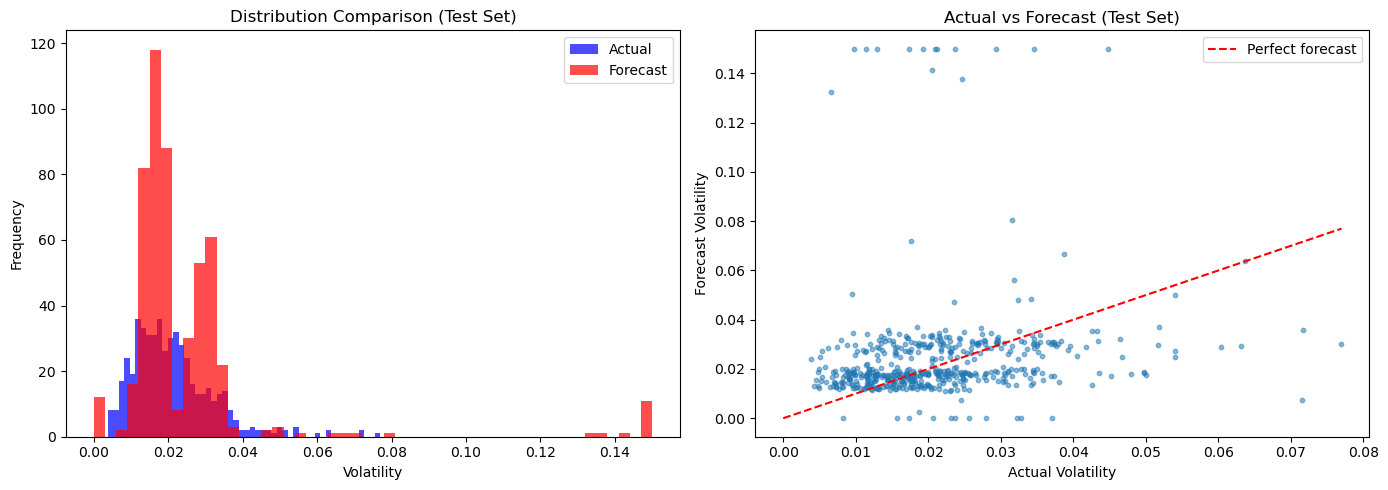


Forecast Statistics (Test Set):
  Mean forecast: 0.024718
  Mean actual:   0.021162
  Forecast std:  0.022424
  Actual std:    0.010971
  Forecasts > Actuals: 54.7%


In [ ]:
# Diagnostic Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(test_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(test_preds, bins=50, alpha=0.7, label='Forecast', color='red')
axes[0].set_xlabel('Volatility')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(test_actuals, test_preds, alpha=0.5, s=10)
axes[1].plot([0, test_actuals.max()], [0, test_actuals.max()], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Volatility')
axes[1].set_ylabel('Forecast Volatility')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.savefig('hmm_egarch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {test_preds.mean():.6f}")
print(f"  Mean actual:   {test_actuals.mean():.6f}")
print(f"  Forecast std:  {test_preds.std():.6f}")
print(f"  Actual std:    {test_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(test_preds > test_actuals).mean()*100:.1f}%")